# Linear Regression (The Math & Algorithm)

### 1. The Goal
Our mission is to find the **Equation of the Line** that best predicts the output ($y$) based on an input ($x$).

> **The Mathematical Model (The Hypothesis):**
> $$y = wx + b$$

**Breakdown of the Variables:**
* **$y$ (Prediction):** What the model predicts (e.g., House Price).
* **$x$ (Feature):** The input data (e.g., Square Footage).
* **$w$ (Weight/Slope):** How important is $x$? (If $w$ is high, a small change in size creates a huge change in price).
* **$b$ (Bias/Intercept):** The baseline. (What is the price of the house even if the size is 0? The base value).

**The Challenge:** We have the $x$ and the correct answers $y$ (from our dataset). We need to find the perfect **$w$** and **$b$**.



### 2. The Judge: The Cost Function (MSE)
Before the computer can learn, it needs to know **how wrong** it is. We use a formula called the **Cost Function** (often denoted as $J$).

**The Logic:**
1.  Make a prediction.
2.  Subtract the Real Answer from the Prediction to find the **Difference**.
3.  **Square** that difference (so negatives become positive and large errors are punished).
4.  Add them all up and divide by the number of samples ($n$) to get the average.

**The Math Equation:**
$$J(w, b) = \frac{1}{n} \sum_{i=1}^{n} (y_{pred} - y_{actual})^2$$

**English Translation:**
"The Cost ($J$) is the Average ($\frac{1}{n}$) Sum ($\Sigma$) of the Squared Errors."



---

---

### 3. The Engine: Gradient Descent
This is the algorithm that actually finds the best $w$ and $b$. It minimizes the Cost Function.

**The Landscape Analogy:**
Imagine the Cost Function is a valley (a bowl shape).
* **Top of the hill:** High Error (Bad model).
* **Bottom of the valley:** Minimum Error (Perfect model).
* **Goal:** Walk down the hill to the very bottom.



**The Math (Simplified Calculus):**
To walk down the hill, we need to know the **Slope** (Gradient) at our current position.
* If the slope is positive, we go the other way (subtract).
* If the slope is negative, we go forward (add).

We calculate the slope using **Derivatives** (don't worry, here are the final formulas we use in code):

**1. Gradient for Weight ($w$):**
$$D_w = \frac{2}{n} \sum (y_{pred} - y_{actual}) \cdot x$$
*(English: The average error multiplied by the input)*

**2. Gradient for Bias ($b$):**
$$D_b = \frac{2}{n} \sum (y_{pred} - y_{actual})$$
*(English: The average error)*

---

---

### 4. The Algorithm in Detail (Step-by-Step)
Here is exactly what happens inside the computer, loop by loop.

**Step 1: Initialization**
* Start with random numbers.
* Let $w = 0$
* Let $b = 0$
* Choose a **Learning Rate** ($L$). This is how big of a step we take (e.g., $0.01$).

**Step 2: The Training Loop (Epochs)**
We repeat the following steps 1000 times (or more):

* **A. Prediction (Forward Pass):**
    Calculate the current prediction using the current $w$ and $b$.
    $$y_{pred} = wx + b$$

* **B. Calculate Gradients (The Direction):**
    How much should we change $w$ and $b$ to reduce error?
    $$D_w = \frac{2}{n} \sum (y_{pred} - y) \cdot x$$
    $$D_b = \frac{2}{n} \sum (y_{pred} - y)$$

* **C. Update Weights (The Step):**
    Move $w$ and $b$ in the opposite direction of the gradient.
    $$w_{new} = w_{old} - (L \times D_w)$$
    $$b_{new} = b_{old} - (L \times D_b)$$

* **D. Repeat:**
    Go back to Step A with the new $w$ and $b$.

**Result:** After many loops, $w$ and $b$ settle at the values that create the line of best fit.



---

---

### 5. Learning Rate: The "Goldilocks" Parameter
The Learning Rate ($L$) is crucial.

* **If $L$ is too big:** You take giant steps. You might step right over the bottom of the valley and bounce up the other side. The model never learns (diverges).
* **If $L$ is too small:** You take tiny baby steps. It will take years to reach the bottom.
* **Just Right:** The model steadily decreases error every loop.

---

---

### 6. Summary Cheat Sheet

| Component | Math Symbol | Meaning |
| :--- | :--- | :--- |
| **Hypothesis** | $y = wx + b$ | The equation of the line. |
| **Cost Function** | $MSE$ | The score of how "bad" the model is. |
| **Gradient** | $D_w, D_b$ | The direction we need to move to fix the error. |
| **Learning Rate** | $L$ (or $\alpha$) | The size of the step we take downhill. |
| **Epochs** | $N$ | How many times we loop through the data. |

---

#########################

--- Model Results ---
Slope (Weight): 0.27 (For every 1 hour studied, score increases by this much)
Intercept (Bias): 5.15 (The base score if you study 0 hours)
Equation: y = 0.27x + 5.15
------------------------------
Prediction for 8.5 hours of study: 7.46 marks
------------------------------
Mean Squared Error (MSE): 0.22
R2 Score (Accuracy): 0.56


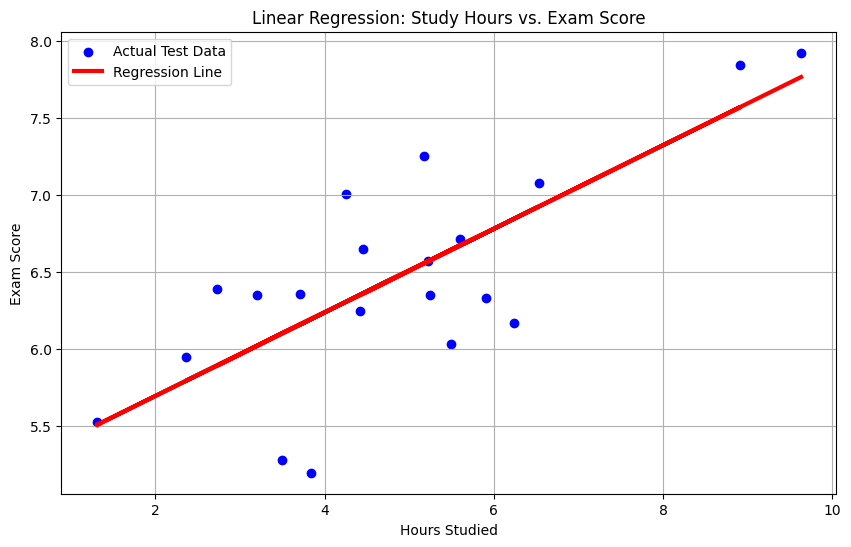

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# ==========================================
# STEP 1: Generate "Actual" Data
# ==========================================
# We create synthetic data to simulate a real classroom scenario.
# Random seed ensures you get the same numbers every time you run this.
np.random.seed(42)

# X = Hours Studied (Random numbers between 1 and 10 hours)
# We generate 100 students
X = 2.5 * np.random.randn(100) + 5
res = 0.5 * np.random.randn(100)       # Generate some "noise" (random variation)
y = 5 + 0.3 * X + res                  # y = Exam Score (Linear relationship + noise)

# NOTE: Scikit-learn expects X to be a 2D array (rows, columns).
# We reshape it to look like a column.
X = X.reshape(-1, 1)

# ==========================================
# STEP 2: Split Data (Train vs Test)
# ==========================================
# We hide 20% of the data to test the model later (The "Exam").
# 80% is used for training (The "Homework").
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# STEP 3: Train the Model
# ==========================================
# Initialize the algorithm
model = LinearRegression()

# This represents the Gradient Descent loop we discussed!
# It finds the best 'm' (slope) and 'c' (intercept).
model.fit(X_train, y_train)

# ==========================================
# STEP 4: Make Predictions
# ==========================================
# Let's predict scores for the Test set
y_pred = model.predict(X_test)

# Let's try a specific prediction:
# If a student studies for 8.5 hours, what will they score?
specific_hours = np.array([[8.5]])
specific_pred = model.predict(specific_hours)

# ==========================================
# STEP 5: Evaluate the Model
# ==========================================
# The Coefficients (The Math found by the model)
m = model.coef_[0]
c = model.intercept_

print("--- Model Results ---")
print(f"Slope (Weight): {m:.2f} (For every 1 hour studied, score increases by this much)")
print(f"Intercept (Bias): {c:.2f} (The base score if you study 0 hours)")
print(f"Equation: y = {m:.2f}x + {c:.2f}")
print("-" * 30)
print(f"Prediction for 8.5 hours of study: {specific_pred[0]:.2f} marks")
print("-" * 30)
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.2f}")
print(f"R2 Score (Accuracy): {r2_score(y_test, y_pred):.2f}")

# ==========================================
# STEP 6: Visualization
# ==========================================
plt.figure(figsize=(10, 6))

# Plot the actual training data (Blue dots)
plt.scatter(X_test, y_test, color='blue', label='Actual Test Data')

# Plot the model's regression line (Red line)
plt.plot(X_test, y_pred, color='red', linewidth=3, label='Regression Line')

plt.title('Linear Regression: Study Hours vs. Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.legend()
plt.grid(True)
plt.show()

########################

# 🎓 The Cost Function (MSE)
**"How wrong is the model?"**

### 1. The Core Concept: The "Golf" Analogy
In most video games or exams, you want a **High Score**.
But in Machine Learning (and Golf), you want the **Lowest Score possible**.

* **The Cost Function ($J$)** is the score.
* **0** is a perfect score (It means the model made zero mistakes).
* **High Number** means the model is terrible.

**Definition:**
The Cost Function is a mathematical formula that calculates the difference between the **Model's Prediction** and the **Actual Answer**.

---

---

### 2. Introducing MSE (Mean Squared Error)
There are many ways to calculate "Cost," but for Linear Regression, the most popular one is **MSE**.

Let's break the acronym down **backwards**:

1.  **Error:** The distance between the Prediction and the Truth.
2.  **Squared:** We multiply the error by itself (Error $\times$ Error).
3.  **Mean:** We take the Average of all these squared errors.



---

---

### 3. The Math

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_{i} - \hat{y}_{i})^2$$

* **$n$**: The number of students (data points).
* **$\Sigma$ (Sigma)**: A fancy instruction that just means **"Add them all up."**
* **$y$**: The **Actual** score (The Truth).
* **$\hat{y}$ (y-hat)**: The **Predicted** score (The Guess).
* **Squared $^2$**: The most important part!

---

---

### 4. The "Why": Why do we Square it? ($^2$)
Students always ask: *"Why not just subtract? Why do we have to square it?"*

There are two massive reasons:

#### Reason A: The "Negative" Problem
Imagine two predictions:
* Prediction 1 is **+10** too high.
* Prediction 2 is **-10** too low.
* If you just add them: $10 + (-10) = 0$.
* **The Problem:** The computer thinks the error is **0** (Perfect), but it was actually wrong twice!
* **The Fix:** Squaring makes everything positive. $10^2 = 100$, $(-10)^2 = 100$. Total Error = 200.

#### Reason B: Punishing Big Mistakes
Squaring punishes the model **severely** for being very wrong.

* **Small Error (2):** $2^2 = 4$ (A small slap on the wrist).
* **Big Error (10):** $10^2 = 100$ (A huge penalty).

**Takeaway:** The MSE screams at the model: *"I don't mind small mistakes, but DO NOT make a big mistake."*



---

---

### 5. A Real Calculation Example (Classroom Walkthrough)
Let's do the math for a class of just 3 students.

**Scenario:** Predicting Test Scores based on Study Hours.

| Student | Actual Score ($y$) | Model Predicted ($\hat{y}$) | Error ($y - \hat{y}$) | Squared Error |
| :--- | :--- | :--- | :--- | :--- |
| **Alice** | 90 | 85 | 5 | **25** |
| **Bob** | 75 | 75 | 0 | **0** |
| **Charlie** | 60 | 64 | -4 | **16** |

**Step 1: Sum the Squared Errors**
$$25 + 0 + 16 = 41$$

**Step 2: Calculate the Mean (Divide by $n=3$)**
$$MSE = \frac{41}{3} = 13.66$$

**Conclusion:** The "Cost" of this model is **13.66**. The computer will now try to adjust the line to get this number lower than 13.66.

---

---

### 6. The "Bowl" Shape (Convexity)
This is important for the next topic (Gradient Descent).
If you plot the MSE Cost Function, it looks like a **Bowl** (or a Parabola).

* Because it is shaped like a bowl, we know there is **one single bottom point** (The Global Minimum).
* This means if we keep going "downhill," we are guaranteed to find the best possible answer.



---

# 🎓 Gradient Descent
**"How the Machine Actually Learns"**
### 1. The Core Analogy: The Blind Mountain Hiker
To understand the math, you first need to visualize the physical action.

> **The Scenario:**
> Imagine you are stuck on top of a mountain at night. It is pitch black. You cannot see anything.
>
> **The Goal:** You need to get to the very bottom of the valley (the lowest point) because that’s where the village (The Solution) is.
>
> **The Strategy:**
> 1.  You feel the ground with your feet.
> 2.  If the ground slopes **down**, you take a step in that direction.
> 3.  If the ground slopes **up**, you go the opposite way.
> 4.  You repeat this, taking step after step, until the ground feels flat. You have reached the bottom.

**In Machine Learning:**
* **The Mountain:** The Cost Function (MSE).
* **Your Position:** The current values of Weights ($w$) and Bias ($b$).
* **The Steepness:** The Gradient (Slope).
* **The Step Size:** The Learning Rate.
* **The Bottom:** The best model with the lowest error.

---

---

### 2. The Math Concept: The "Gradient" (Slope)
Mathematically, how do we "feel the slope"? We use **Calculus**. Specifically, a **Derivative**.


* **The Gradient** is simply the **Slope of the curve** at a specific point.
* It tells you two things:
    1.  **Direction:** Which way is "down"?
    2.  **Magnitude:** How steep is it? (Steep slope = Big mistake = Big step needed).



---

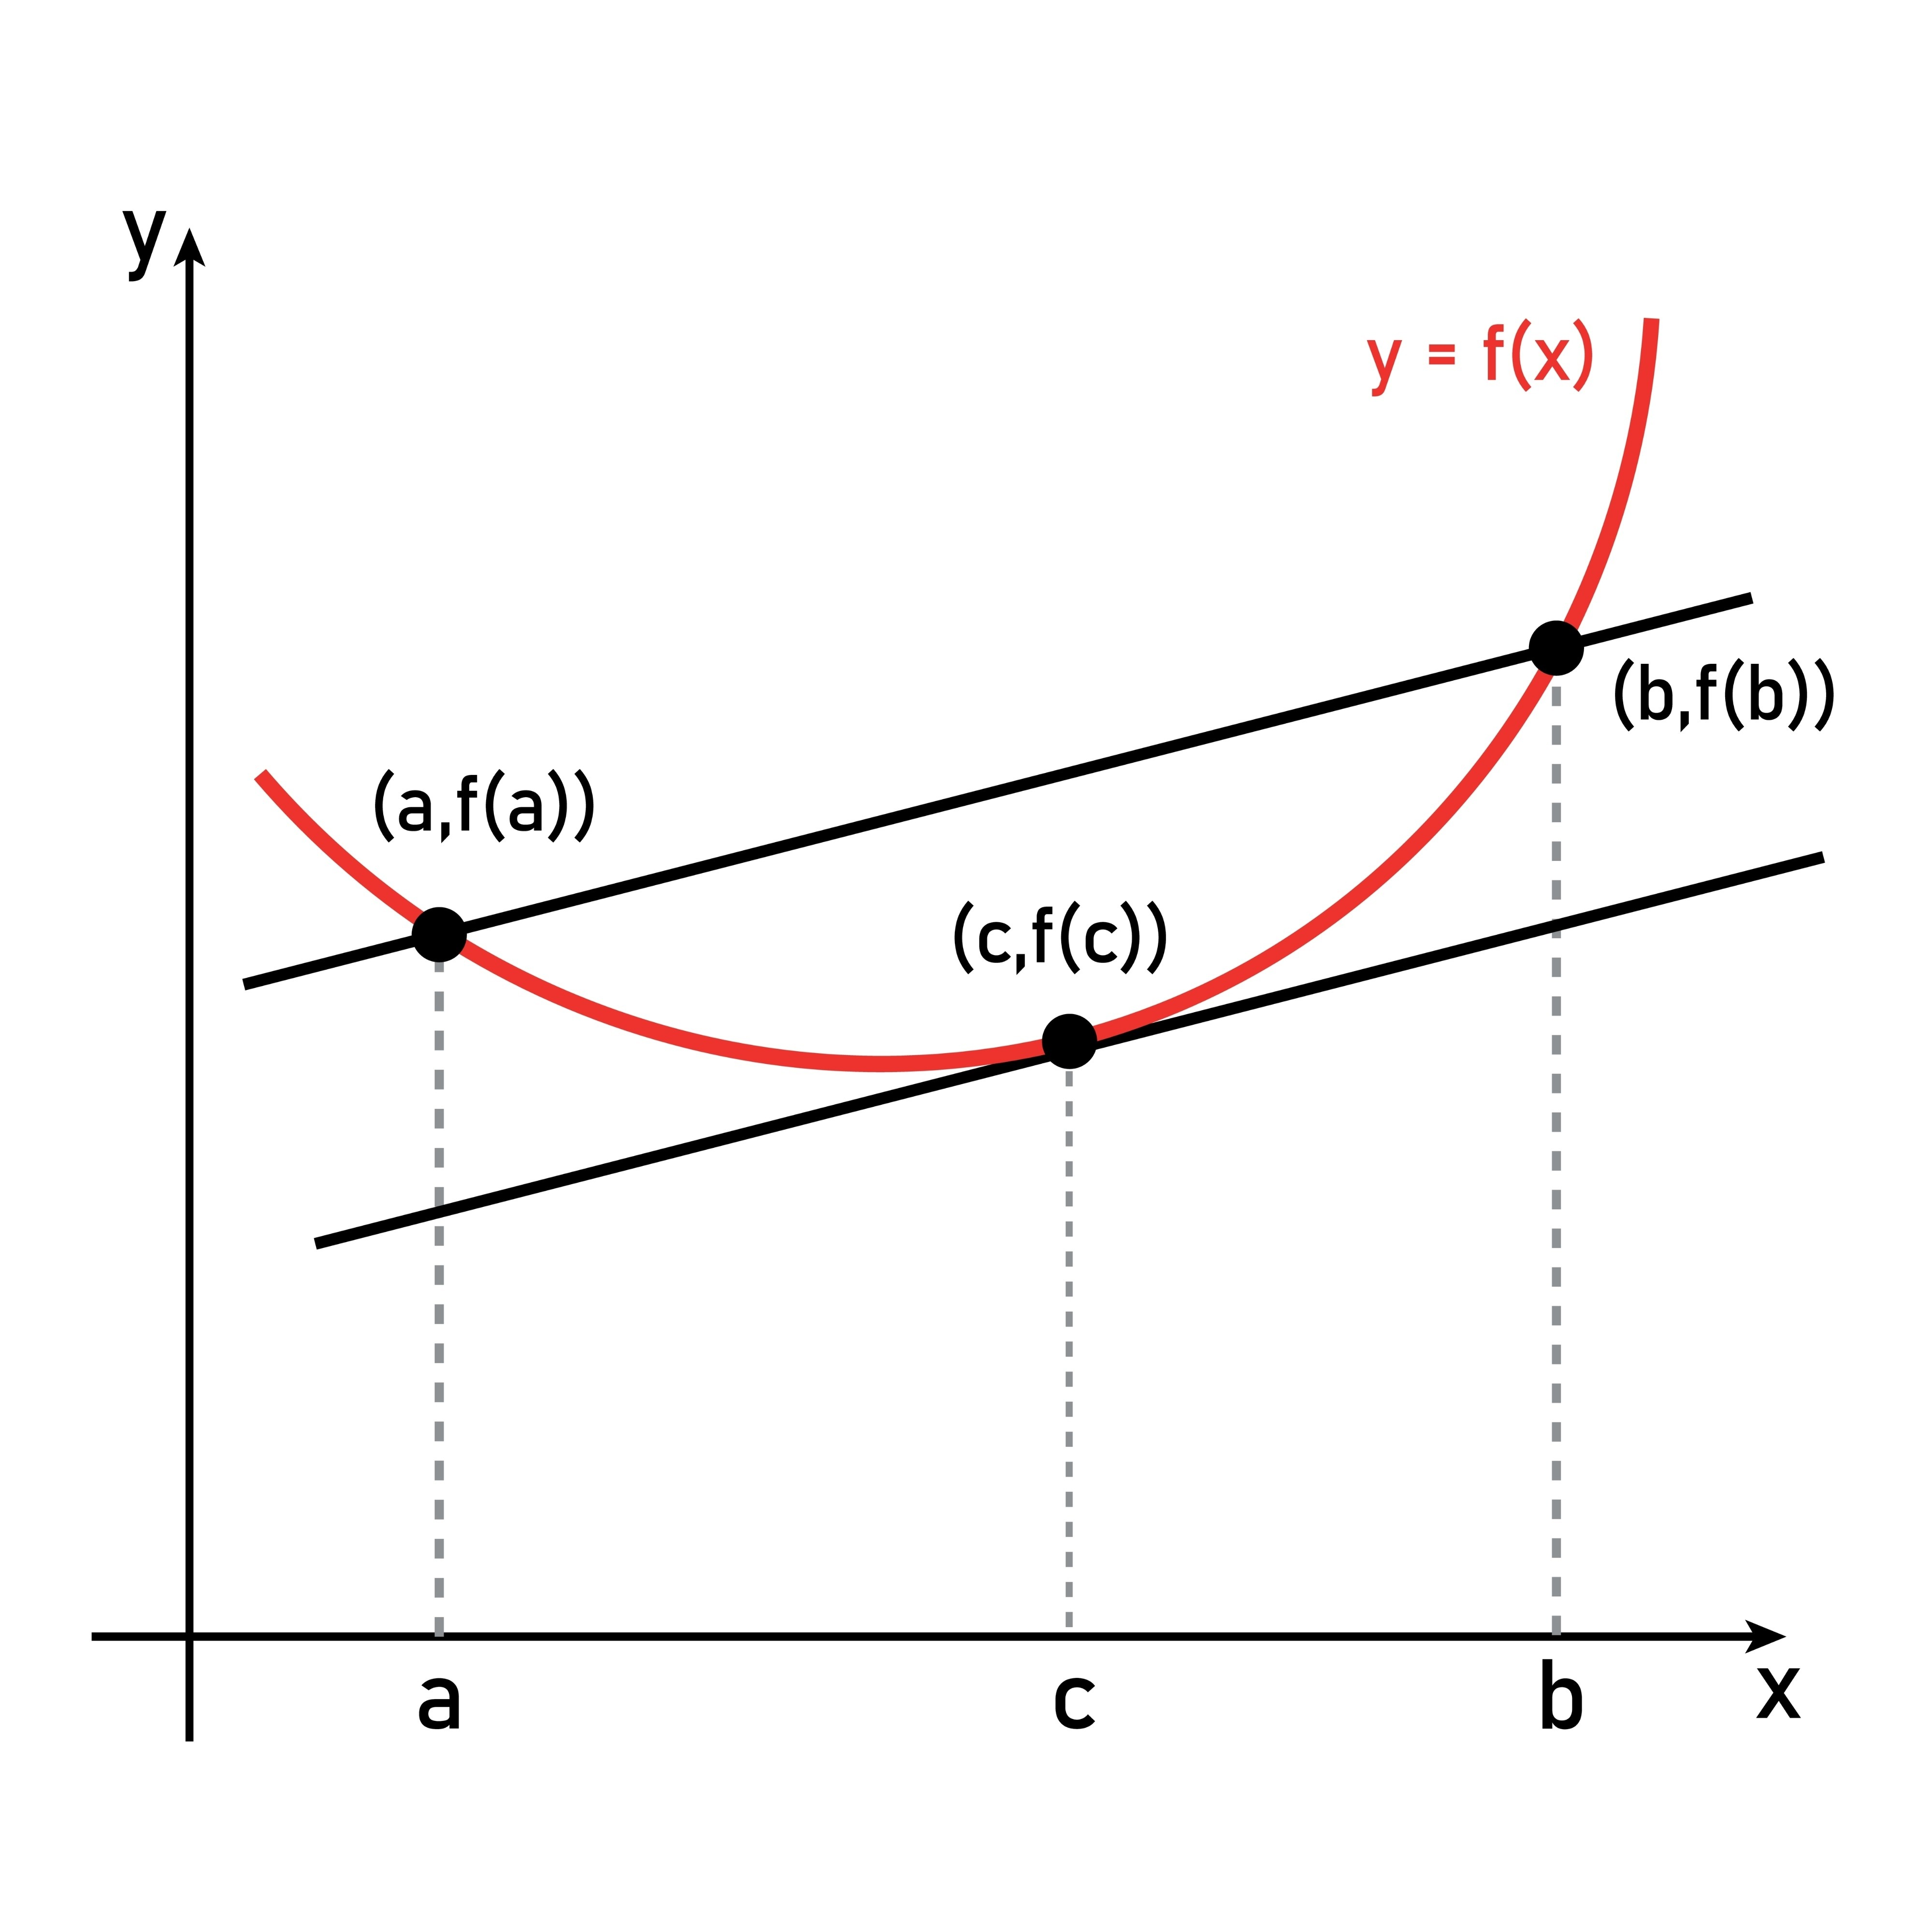

---

### 3. The "Golden Formula": The Update Rule


$$w_{new} = w_{old} - (\alpha \times \frac{\partial J}{\partial w})$$



1.  **$w_{new}$**: The new, smarter weight.
2.  **$w_{old}$**: The current, dumb weight.
3.  **$-$ (Minus Sign)**: This is crucial!
    * If the slope is positive (going up), we want to go *backwards* (decrease $w$).
    * If the slope is negative (going down), we want to go *forwards* (increase $w$).
    * The minus sign ensures we always move **opposite** to the slope, towards the bottom.
4.  **$\alpha$ (Alpha)**: The **Learning Rate** (Step Size).
5.  **$\frac{\partial J}{\partial w}$**: The **Gradient** (The Slope calculated by Calculus).

---


---

### 4. The Math Behind the Gradient (For Linear Regression)
You might ask: *"How do we calculate that slope part ($\frac{\partial J}{\partial w}$)?"*

For Linear Regression, we use the Chain Rule (Calculus)

**The Logic:**
The Slope = (Prediction - Actual) $\times$ Input.

**The Math Equation:**
$$Gradient = \frac{2}{n} \sum (y_{predicted} - y_{actual}) \cdot x$$

* **Why is $x$ there?** Because if the input ($x$) is big, a wrong weight causes a huge error, so the slope is steeper.
* **Why $(y_{pred} - y_{act})$?** This is the Error. Bigger error = Steeper slope.

---

---

### 5. The Learning Rate ($\alpha$): Step Size Matters
This is the knob you turn to control how fast the model learns.

> **The "Goldilocks" Scenarios:**
>
> 1.  **Too Small (Baby Steps):**
>     * You take microscopic steps.
>     * **Result:** It takes 10 years to get down the mountain. The model is too slow.
>
> 2.  **Too Big (Giant Leaps):**
>     * You jump so far you overshoot the bottom and land on the other side of the valley.
>     * **Result:** You bounce back and forth and never reach the bottom. The model diverges (explodes).
>
> 3.  **Just Right:**
>     * You take confident steps initially, and smaller steps as you get closer to the target.




---

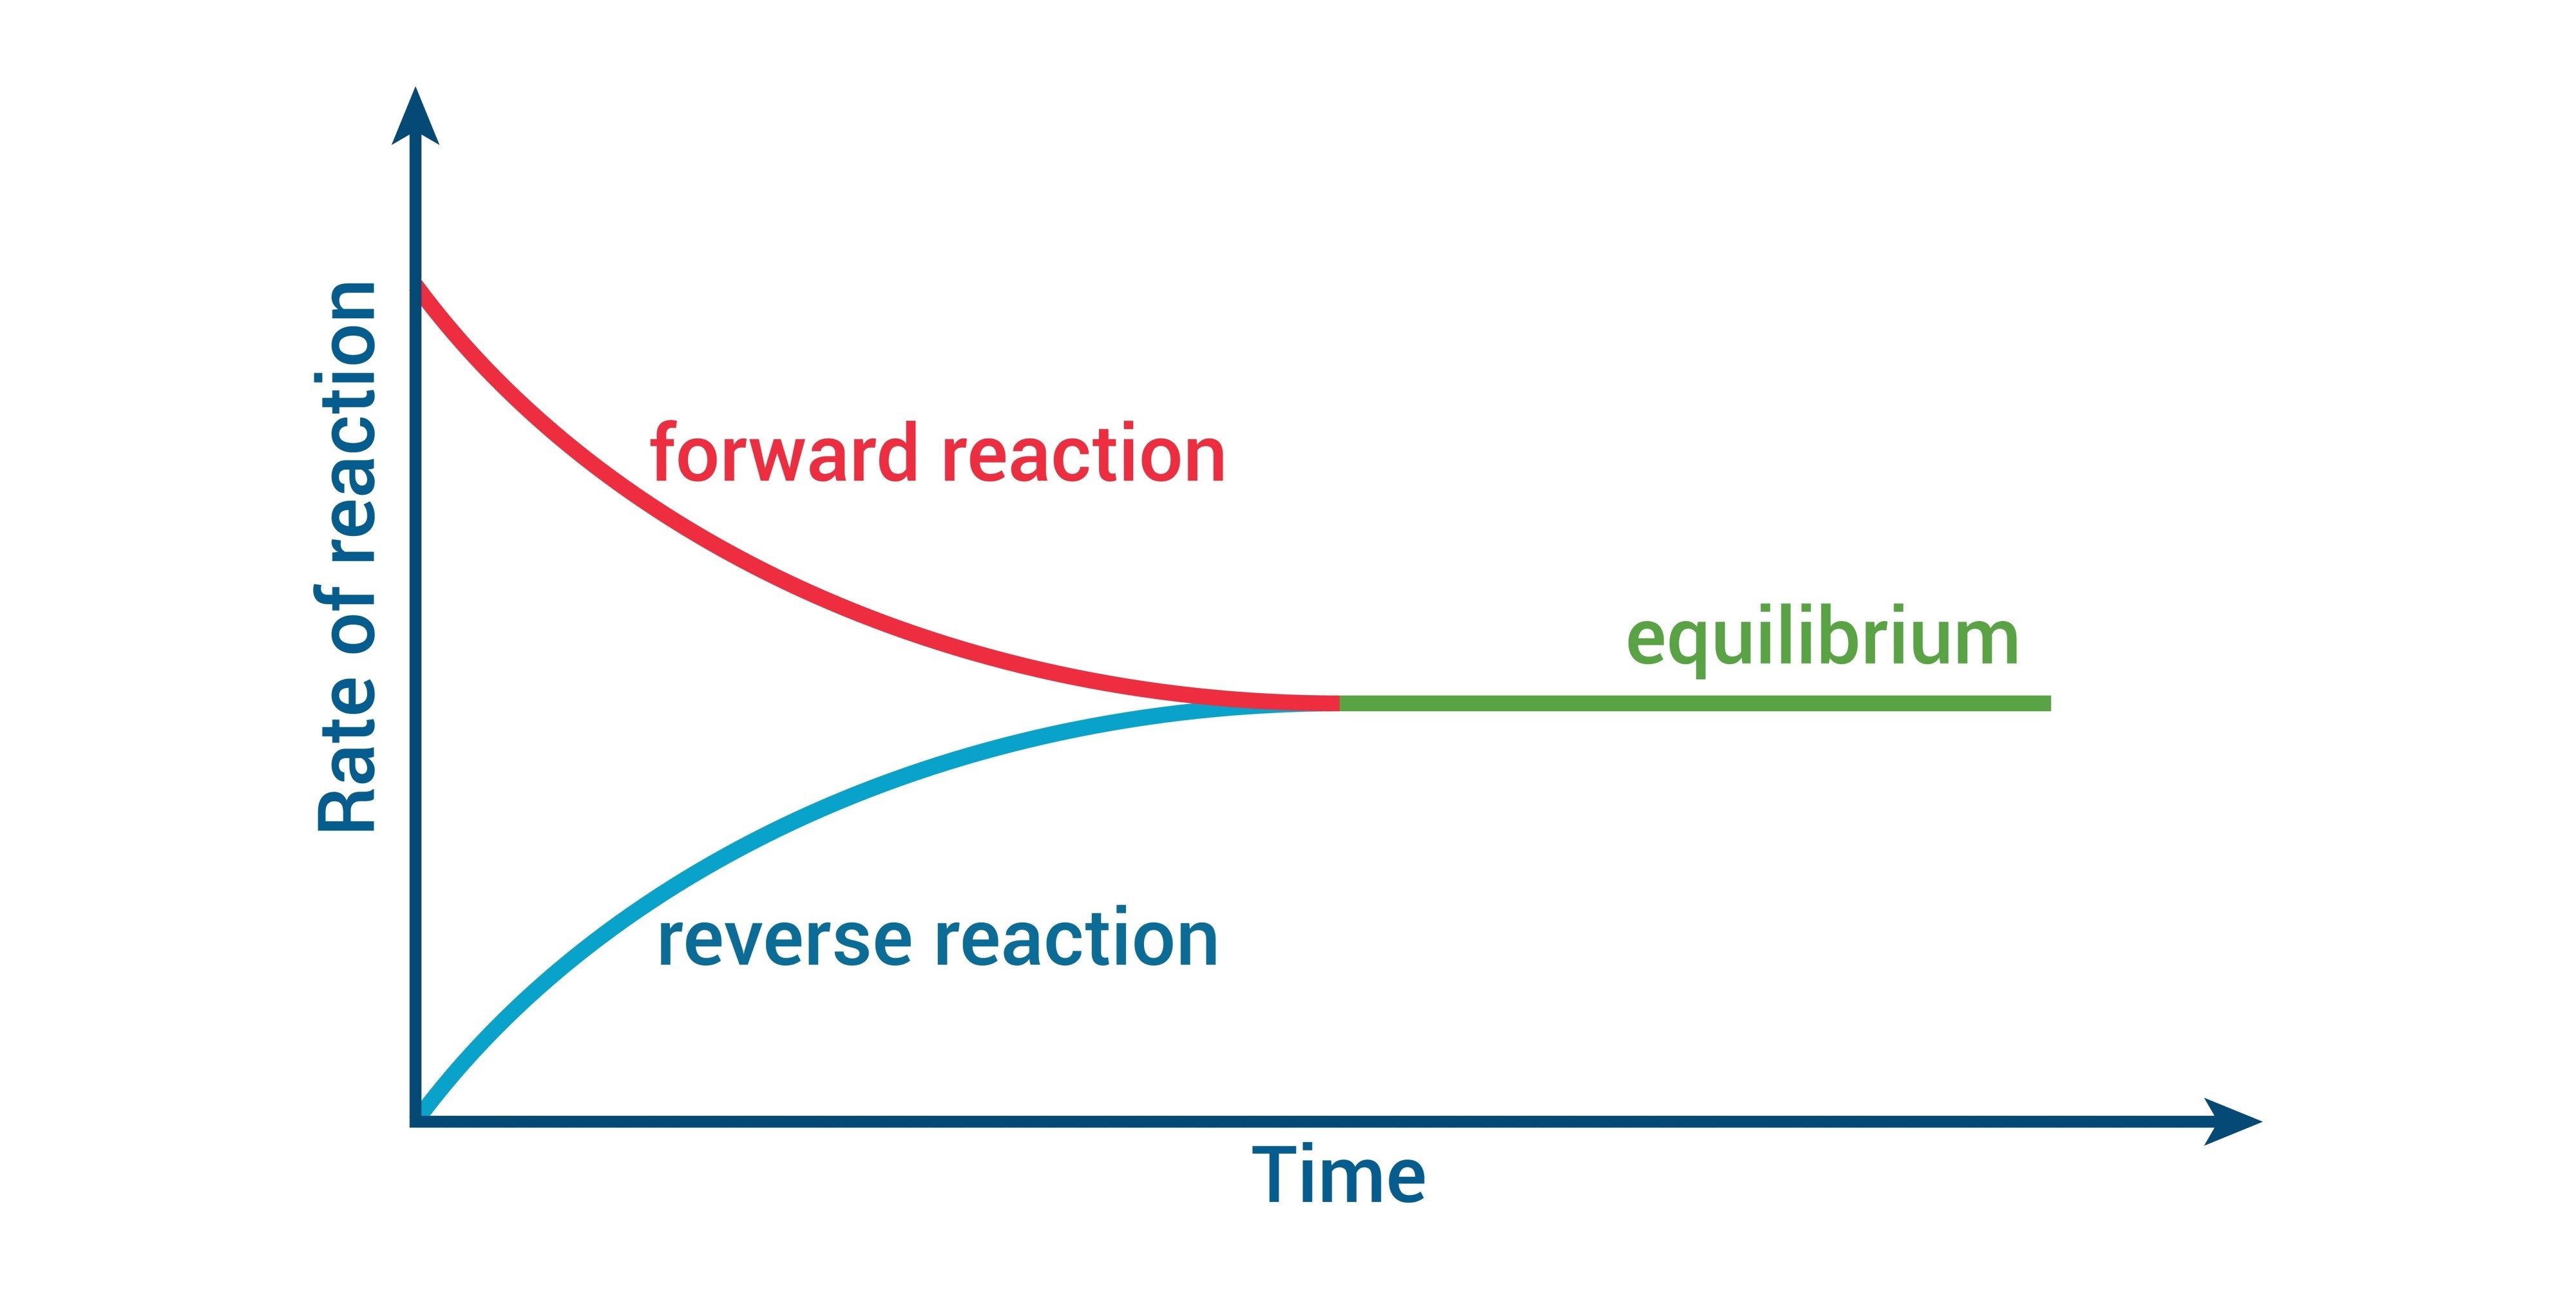

---

### 6. Summary: The Full Algorithm Loop
Here is the pseudocode logic :

1.  **Start:** Pick a random $w$ (e.g., 0).
2.  **Loop:**
    * Calculate the Error (MSE).
    * Calculate the Gradient (Slope) using the formula.
    * Update $w$ using the "Golden Formula": $w = w - (LearningRate \times Gradient)$.
3.  **Stop:** When the step size becomes almost zero (the slope is flat), we are at the bottom.

---

---

### 7. Types of Gradient Descent (Briefly)
There isn't just one way to walk down the hill.

* **Batch Gradient Descent:** Use **all** the data points to calculate the slope before taking **one** step. (Accurate but slow).
* **Stochastic Gradient Descent (SGD):** Use **one** random data point to calculate the slope and take a step. (Fast but messy/bumpy).
* **Mini-Batch GD:** The best of both worlds. Use a small group (e.g., 32 data points) to take a step.

---